# Panel overlap — v3 vs GrENE-Net 231 SNP catalog

How much of the GrENE-Net 231-founder SNP catalog (the panel hapFIRE consumes) is also represented in the v3 cactus_em panel?

Both panels cover the **same 231 founders**. Comparison is direct (chrom, pos) intersection — no founder-subset complication needed.

## Three different SNP-position counts in v3 to consider

- `v3_snp_positions` — biallelic SNPs only (most apples-to-apples with GrENE-Net's biallelic SNP catalog)
- `v3_snp_positions_dedup` — all SNPs (incl. multi-allelic), deduplicated to unique (chrom, pos) — equivalent to "any SNP at this position"
- `v3_all_positions` — every variant in v3 (SNPs + indels + SVs + multi-allelic atoms) — broadest possible position list

Plus the GrENE-Net catalog: 3,235,480 SNP positions.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

DATA = Path('/global/scratch/users/tbellg/hapfire_sv/panel_overlap_v3_grenenet/data')

def load_pos(path):
    df = pd.read_csv(path, sep='\t', header=None, names=['chrom','pos'],
                     dtype={'chrom':str, 'pos':np.int64})
    return df

# GrENE-Net (chrom names: '1','2',...)
gn = load_pos(DATA/'grenenet231_snp_positions.tsv')
print(f'GrENE-Net 231 SNP sites: {len(gn):,}')
print(f'  chroms: {sorted(gn.chrom.unique())}')

# v3 in 3 versions (use the .nochr.tsv to match GrENE-Net naming)
v3_all   = load_pos(DATA/'v3_all_positions.nochr.tsv')
v3_snp   = load_pos(DATA/'v3_snp_positions.nochr.tsv')
v3_dedup = load_pos(DATA/'v3_snp_positions_dedup.nochr.tsv')
print(f'\nv3 ALL positions:                     {len(v3_all):>10,}')
print(f'v3 biallelic SNP positions:           {len(v3_snp):>10,}')
print(f'v3 SNP positions dedup (incl. multi): {len(v3_dedup):>10,}')
print(f'  chroms in v3: {sorted(v3_all.chrom.unique())}')


GrENE-Net 231 SNP sites: 3,235,480
  chroms: ['1', '2', '3', '4', '5']



v3 ALL positions:                      7,693,558
v3 biallelic SNP positions:            5,010,051
v3 SNP positions dedup (incl. multi):  4,426,208


  chroms in v3: ['1', '2', '3', '4', '5']


## Compute overlap (3-way against GrENE-Net biallelic SNPs)

For each v3 position list, compute:
- `|v3 ∩ GrENE-Net|` — shared positions
- `|GrENE-Net only|` — sites in GrENE-Net but missing from v3 → hapFIRE estimates h here, can't be projected through cn_var_v3
- `|v3 only|` — sites in v3 but not in GrENE-Net → cactus_em can predict here, hapFIRE doesn't see them


In [2]:
def to_set(df):
    return set(zip(df.chrom.astype(str), df.pos.astype(np.int64)))

gn_set = to_set(gn[gn.chrom.isin(['1','2','3','4','5'])])
print(f'GrENE-Net set: {len(gn_set):,}')

def venn_counts(v3_df, label):
    v3_set = to_set(v3_df[v3_df.chrom.isin(['1','2','3','4','5'])])
    shared = v3_set & gn_set
    only_v3 = v3_set - gn_set
    only_gn = gn_set - v3_set
    return {
        'label': label,
        'n_v3': len(v3_set),
        'n_gn': len(gn_set),
        'shared': len(shared),
        'only_v3': len(only_v3),
        'only_gn': len(only_gn),
        'pct_gn_in_v3': 100 * len(shared) / max(len(gn_set), 1),
        'pct_v3_in_gn': 100 * len(shared) / max(len(v3_set), 1),
    }

results = [
    venn_counts(v3_snp,   'v3 biallelic SNP only'),
    venn_counts(v3_dedup, 'v3 SNP dedup (incl. multi-allelic)'),
    venn_counts(v3_all,   'v3 ALL positions (SNP + indel + SV + multi)'),
]
res_df = pd.DataFrame(results).set_index('label')
print(res_df.to_string())


GrENE-Net set: 3,235,480


                                                n_v3     n_gn   shared  only_v3  only_gn  pct_gn_in_v3  pct_v3_in_gn
label                                                                                                               
v3 biallelic SNP only                        4426208  3235480  1781226  2644982  1454254     55.052913     40.242709
v3 SNP dedup (incl. multi-allelic)           4426208  3235480  1781226  2644982  1454254     55.052913     40.242709
v3 ALL positions (SNP + indel + SV + multi)  5214959  3235480  1817925  3397034  1417555     56.187181     34.859814


## Headline interpretation

The `pct_gn_in_v3` column = the fraction of GrENE-Net SNPs **reachable** by cactus_em projection. The complement (`100 - pct_gn_in_v3`) = the fraction of GrENE-Net SNPs **silently lost** when projecting hapFIRE-h through cn_var_v3 (these positions get NaN or are missing from the projected output).

The `pct_v3_in_gn` column = the fraction of v3 positions hapFIRE could in principle estimate h for — anything outside this is a v3-exclusive variant (incl. SVs and PG-specific variants).


## Venn diagrams — three v3 position-sets vs GrENE-Net


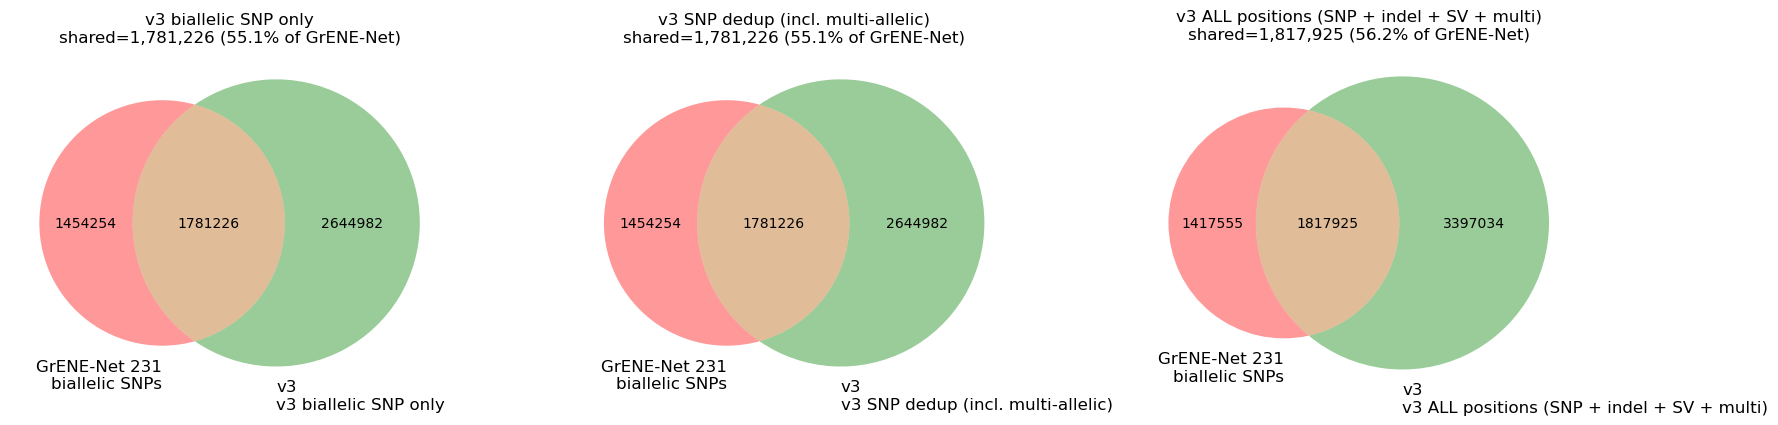

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, r in zip(axes, results):
    venn2(subsets=(r['only_gn'], r['only_v3'], r['shared']),
          set_labels=('GrENE-Net 231\nbiallelic SNPs', f'v3\n{r["label"]}'),
          ax=ax)
    ax.set_title(f'{r["label"]}\n'
                 f'shared={r["shared"]:,} ({r["pct_gn_in_v3"]:.1f}% of GrENE-Net)')
plt.tight_layout()
plt.show()


## Per-chromosome breakdown — v3 biallelic SNPs vs GrENE-Net


In [4]:
rows = []
for ch in ['1','2','3','4','5']:
    gn_c = to_set(gn[gn.chrom==ch])
    v3_c = to_set(v3_snp[v3_snp.chrom==ch])
    sh = gn_c & v3_c
    rows.append({
        'chrom': f'Chr{ch}',
        'gn_snps': len(gn_c),
        'v3_snps': len(v3_c),
        'shared': len(sh),
        'pct_gn_in_v3': 100 * len(sh) / max(len(gn_c), 1),
        'gn_only': len(gn_c - v3_c),
        'v3_only': len(v3_c - gn_c),
    })
print(pd.DataFrame(rows).set_index('chrom').to_string())


       gn_snps  v3_snps  shared  pct_gn_in_v3  gn_only  v3_only
chrom                                                          
Chr1    827765  1112968  468661     56.617639   359104   644307
Chr2    536387   721753  277051     51.651326   259336   444702
Chr3    617020   857992  334290     54.178147   282730   523702
Chr4    531361   723130  286182     53.858300   245179   436948
Chr5    722947  1010365  415042     57.409741   307905   595323


## Implications for the hapfire-projected-through-cn_var_v3 method

Whenever we run `hapfire_v2panel_v3proj` (or `hapfire_coarse_v3proj`), we project hapFIRE's per-block h estimates through `cn_var_v3` to get per-record AFs. This step:

- **Recovers AFs for v3 records that are GrENE-Net SNPs** (the shared set in the Venn).
- **Misses GrENE-Net SNPs absent from v3** — these are silently dropped from the output (no row in the projected TSV). The fraction here = `100 - pct_gn_in_v3`.
- **Adds AF predictions at v3-exclusive records** (indels, SVs, PG-specific) — hapFIRE's per-block h is reused as the founder mass at those positions even though hapFIRE never saw them. Whether that's a fair prediction depends on whether the per-block h in the GrENE-Net SNP catalog accurately reflects the founder mix at indel/SV positions in cn_var_v3.

The key takeaway for production: the **silent-loss fraction** matters most. Higher = more sites where hapFIRE's estimate is throwaway when consumed by cactus_em-aligned downstream tools.
